In [8]:
!pip install pykeen

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.3 MB/s eta 0:00:00


##Pykeen Pipeline for Rotate-E model

In [2]:

import torch
from pykeen.pipeline import pipeline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

if device == 'cpu':
    print("switch to gpu")


pipeline_result = pipeline(
    dataset='FB15k237',
    model='RotatE',

    # 512 dimensions , a higher value as compared to the ones we used in rgcn adn compgcn because the model is learning from scratch here
    model_kwargs=dict(embedding_dim=512),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=0.0005),

    #Adversarial loss
    loss='nssa',
    loss_kwargs=dict(margin=9.0, adversarial_temperature=1.0),

    training_loop='slcwa',
    negative_sampler_kwargs=dict(num_negs_per_pos=128), # 128 fake tests per fact

    training_kwargs=dict(num_epochs=250, batch_size=512),
    stopper='early',
    stopper_kwargs=dict(
        frequency=5,
        patience=10,
        relative_delta=0.002
    ),

    evaluator='RankBasedEvaluator',
    device=device,
    random_seed=42,
)

# Results
print("\n" + "="*50)
print("TRAINING COMPLETE, FINAL BENCHMARK SCORES:")
print("="*50)

mrr = pipeline_result.metric_results.get_metric('mrr')
hits10 = pipeline_result.metric_results.get_metric('hits@10')
hits3 = pipeline_result.metric_results.get_metric('hits@3')
hits1 = pipeline_result.metric_results.get_metric('hits@1')

print(f"Global MRR:       {mrr:.4f}")
print(f"Global Hits@1:   {hits1*100:.2f}%")
print(f"Global Hits@3:   {hits3*100:.2f}%")
print(f"Global Hits@10:  {hits10*100:.2f}%")
print(f"Stopped at Epoch: {pipeline_result.training_loop.epoch}")
print("="*50)


pipeline_result.save_to_directory('/content/RotatE_SOTA_Model')
print("Model saved to /content/RotatE_SOTA_Model")

INFO:pykeen.utils:Using opt_einsum
INFO:pykeen.datasets.utils:Caching preprocessed dataset to file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM
INFO:pykeen.datasets.base:downloading data from https://download.microsoft.com/download/8/7/0/8700516A-AB3D-4850-B4BB-805C515AECE1/FB15K-237.2.zip to /root/.data/pykeen/datasets/fb15k237/FB15K-237.2.zip


Device: cuda


INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=14505, num_relations=237, create_inverse_triples=False, num_triples=272115, path=Release/train.txt) to file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.datasets.base:Stored training factory to file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/training
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=14505, num_relations=237, create_inverse_triples=False, num_triples=20438, path=Release/test.txt) to file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/testing
INFO:pykeen.datasets.base:Stored testing factory to file:///root/.data/pykeen/datasets/fb15k237/cache/47DEQpj8HBSa-_TImW-5JCeuQeRkm5NM/testing
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=14505, num_relations=237, create_inverse_triples=False, num_triples=17526, path=Release/valid.txt) to file:///ro

Training epochs on cuda:0:   0%|          | 0/250 [00:00<?, ?epoch/s]

Training batches on cuda:0:   0%|          | 0.00/532 [00:00<?, ?batch/s]

...

INFO:pykeen.evaluation.evaluator:Evaluation took 28.15s seconds


Evaluating on cuda:0:   0%|          | 0.00/20.4k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 32.79s seconds



TRAINING COMPLETE, FINAL BENCHMARK SCORES:
Global MRR:       0.3351
Global Hits@1:   23.78%
Global Hits@3:   37.27%
Global Hits@10:  53.07%


AttributeError: 'SLCWATrainingLoop' object has no attribute 'epoch'

##Training Loss curve

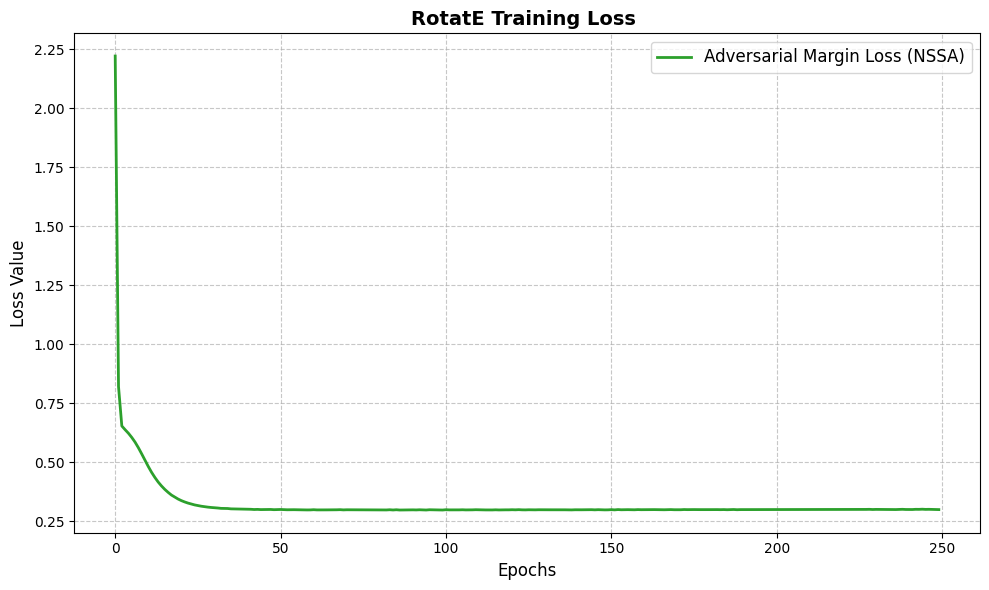

In [13]:

import zipfile
import json
import matplotlib.pyplot as plt
import os

zip_path = '/content/drive/MyDrive/Rotate-E-GNN/RotatE_SOTA_Backup.zip'
extract_dir = '/content/RotatE_Extracted'


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


json_path = f'{extract_dir}/results.json'
if not os.path.exists(json_path):
    # Fallback
    json_path = f'{extract_dir}/RotatE_SOTA_Backup-2/results.json'



# Loading file
with open(json_path, 'r') as f:
    results = json.load(f)

losses = results.get('losses', [])

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses, color='#2ca02c', linewidth=2, label='Adversarial Margin Loss (NSSA)')
plt.title('RotatE Training Loss ', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

##T-SNE on node and relation embeddings

calculating Graph Degrees from FB15k-237


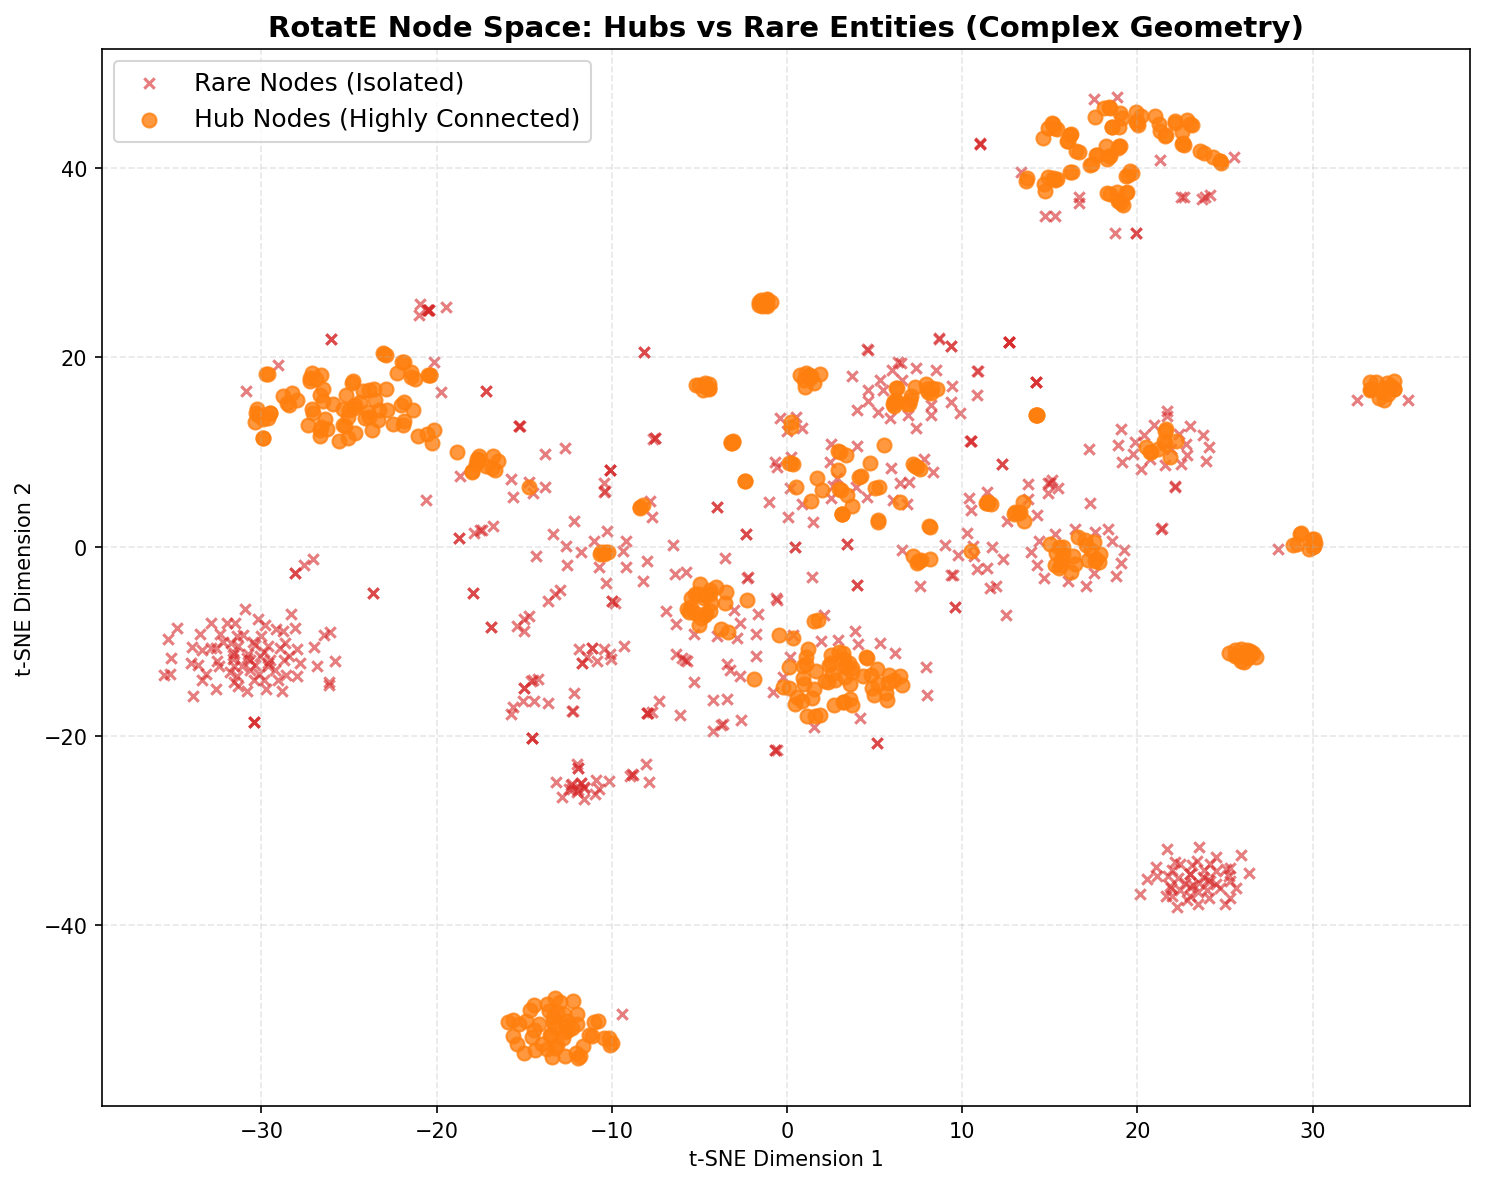

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from pykeen.datasets import FB15k237

extract_path = '/content/RotatE_Extracted/RotatE_SOTA_Backup-2'


model = torch.load(f'{extract_path}/trained_model.pkl', map_location='cpu', weights_only=False)

# Extract Entity Embeddings
node_embs = model.entity_representations[0](indices=None).detach().cpu().numpy()


print("calculating Graph Degrees from FB15k-237")
dataset = FB15k237()
train_triples = dataset.training.mapped_triples.cpu()

degrees = torch.bincount(train_triples[:, 0], minlength=dataset.training.num_entities) + \
          torch.bincount(train_triples[:, 2], minlength=dataset.training.num_entities)

valid_mask = degrees > 0
valid_indices = torch.where(valid_mask)[0]
valid_degrees = degrees[valid_mask]

sorted_valid_indices = valid_indices[torch.argsort(valid_degrees, descending=True)]

hub_ids = sorted_valid_indices[:500].numpy()
rare_ids = sorted_valid_indices[-500:].numpy()



subset_ids = np.concatenate([hub_ids, rare_ids])
subset_embs_complex = node_embs[subset_ids]

# Split Real and Imaginary, then concatenate them side-by-side
subset_embs_real = np.concatenate([np.real(subset_embs_complex), np.imag(subset_embs_complex)], axis=1)


tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(subset_embs_real)

hubs_2d = tsne_2d[:500]
rares_2d = tsne_2d[500:]

# Scatter Plot
plt.figure(figsize=(10, 8), dpi=150)
plt.scatter(rares_2d[:, 0], rares_2d[:, 1], c='#d62728', label='Rare Nodes (Isolated)', alpha=0.6, s=25, marker='x')
plt.scatter(hubs_2d[:, 0], hubs_2d[:, 1], c='#ff7f0e', label='Hub Nodes (Highly Connected)', alpha=0.8, s=45, marker='o')

plt.title('RotatE Node Space: Hubs vs Rare Entities (Complex Geometry)', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

file_name = 'rotate_tsne_nodes.png'
plt.savefig(file_name)
plt.show()

